<a href="https://colab.research.google.com/github/Subroy1/Data-Strategy-for-Leaders/blob/main/Module%2011/PracticalAssignement2_used_cars_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

<span style="color:blue">**UNDERSTAND THE OBJECTIVE FIRST**</span>

Worldwide, used car sales is a major business occupuation due to its ability to provide affordable transportation to millions of citizens.

Though there is no one-size-fits-all solution as location , region , country , avaiability of public mode of transportation , purpose of owning a car etc and affordability based on demographics also play a part, this exercise makes an effort to understand the fundamental principles of Machine learning algorithm,, specifically LR techniques (Linear and Multiple Linear , Ridge ,Lasso and Elastic Net regression models) in order to price cars based on available features and derived features with additional application of domain knowledge in this field.

Furthermore, since the size of the dataset is huge (400K plus), in order to avoid the model from memorizing the relationships between independent and target variable (price), L1 and L2 regularization and subsequent hyperparamter tuning have been relied upon for creating the optimum model.

During the course of implementing this data mining problem , we would have to constantly refine our solution by not only going back to refine data as needed and repeated remodelling but also by enriching our business understanding from evaluation step.

Finally a summart report would be provided to the intended audience namely used car dealers or franchises who would restructure their inventory accordingly to boost sales.

In [3]:
# All of the imports needed for the exercise consolidated in the beginning .
#Standard imports
import pandas as pd
import numpy as np

#scikit-learn libs
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler , TargetEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Plotting libs
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

**Loading the Data**



In [4]:
df = pd.read_csv("/content/sample_data/vehicles.csv")
df.shape

(426880, 18)

# Data Dictionary

*  **price - Our target variable**
*  manufacturer - company manufacturing the brand
*  model - model of the specific make of the car
*  year- year of manufacturing the car or bought by 1st owner
*  transmission - whether manual or automatic gear  
*  drive - whether all wheel drive or 2 wheel drive (Front or rear)
*  state - place where car is registered/ manufactured
*  region- region within the state
*  condition - good or bad (ordinal feature , might need encoding )
*  cylinders- specific to the combustion engine , applicable for petrol and diesel cars only
*   size- such as small , medium , SUV- large , coupe , sedan -medium like that *(might need encoding )
*   fuel- whether runs on gasoline or  diesel , electric (encoding needed)
*   title_status - in which form is the vehicle , it is clean , or rebuilt etc .
* paint_color - car color hardly plays any role in prediction
* odometer- the mileage of the car, how many miles / kms it has driven
* id , VIN - identifiers which do not play any role in predictive algorithms (should be dropped for model building)
* type- utility of the vehicle such as pick up or the structure such as sedan or coupe etc

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Identify numeric and categorical features , also commenting whether we can do any data cleaning or transform into numerical without needing encoder always.

**Data Preprocessing**

Data Cleaning - Broadly, we will follow the following principle .
1. Any cleaning based on domain knowledge and hence identifying outliers would be done pre train_test_split
2. Any data preprocessing including data cleaning based on statistical properties would be done after train test split to avoid data leakage.





**Following CRISP -DM model**
We would first understand the data, describe the statistical properties , observe the categorical and numerical columns (features), define the features for understability .

We will also inspect the quality of the data , null values and any transformations needed.



In [5]:
# Describe the categorical features
df.describe(include="object")

,region,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,state
count,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426880
unique,404,42,29649,6,8,5,6,3,118246,3,4,13,12,51
top,columbus,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,ca
freq,3608,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,50614


In [6]:
# initial random inspection as first few records were NaN for majority of columns in the dataset
df.iloc[150000:150002]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
150000,7303124206,bloomington,38590,2019.0,ram,1500 crew cab big horn,good,6 cylinders,gas,28556.0,clean,other,1C6RRFFGXKN695394,4wd,NaN,pickup,white,in
150001,7303087652,bloomington,43990,2019.0,ram,1500 crew cab big horn,good,8 cylinders,gas,17352.0,clean,other,1C6SRFFT7KN755503,4wd,NaN,pickup,black,in


In [7]:
df.describe().apply(lambda s: s.apply('{0:.5f}'.format))# Print numerical values , maximum price is abnormal and points to data outliers or errors.

,id,price,year,odometer
count,426880.00000,426880.00000,425675.00000,422480.00000
mean,7311486634.22433,75199.03319,2011.23519,98043.33144
std,4473170.41256,12182282.17360,9.45212,213881.50080
min,7207408119.00000,0.00000,1900.00000,0.00000
25%,7308143339.25000,5900.00000,2008.00000,37704.00000
50%,7312620821.00000,13950.00000,2013.00000,85548.00000
75%,7315253543.50000,26485.75000,2017.00000,133542.50000
max,7317101084.00000,3736928711.00000,2022.00000,10000000.00000


In [8]:
#  Display information about columns
df.info() # too many null columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [9]:
# Inpsect null values in the dataset , aim to identify null features adding no usability for prediction such as identifiers .
#calculate percentage of missing values for each variable , sorting descending on pct.
Total=df.isnull().sum()
Percent = (df.isnull().sum()*100/df.isnull().count()).sort_values(ascending=False)
# concat the 'Total' and 'Percent' columns using 'concat' function
# pass a list of column names in parameter 'keys'

missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])
missing_data.sort_values(by='Total', ascending=False)


,Total,Percentage of Missing Values
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
VIN,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753
model,5277,1.236179


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [10]:
# DATA CLEANING
#1. remove id and VIN as they dont add any value to model for predictions .
#2. size is missing from 71% , the model and make already indicate what would be the size , hence fair to drop it as it is redundant and would introduce noise and multicollinearity .
#3  similarly , type feature can be dropped as well because make and model also indicate the type , any dealer or buyer knows what they're buying .
df = df.drop(columns={"id","VIN","size","type"})
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'paint_color', 'state'],
      dtype='object')

In [11]:
# Remove duplicates
# check for duplicate
#duplicate_rows = df[df.duplicated()]
df= df.drop_duplicates()
df.shape

(370256, 14)

In [12]:
# In order to eliminate bizzare values , remove the top 0.001% highest priced cars that are certainly erroneous , without loss of generality.
price_upper_bound = np.quantile(df['price'], 0.999)
df = df[df['price'] <= price_upper_bound]
df['price'].max() # ~ 120,000 which is reasonable enough to build a simple model. There would be some very expensive cars outliers, but this is an approximation. Only 367 further cars removed .

122420

In [13]:
# even then  lots of values if sorted in ascending can be seen to be 0s and 1 ,
#points to lots of errors still exist, a car price should be at least around 1500 to be considered a reasonable sale in a decent model.
df= df[df['price']>1000]
df['price'].sort_values(ascending=False).head(2)


,price
98920,122420
290197,122420


#Plot the price as Target variable

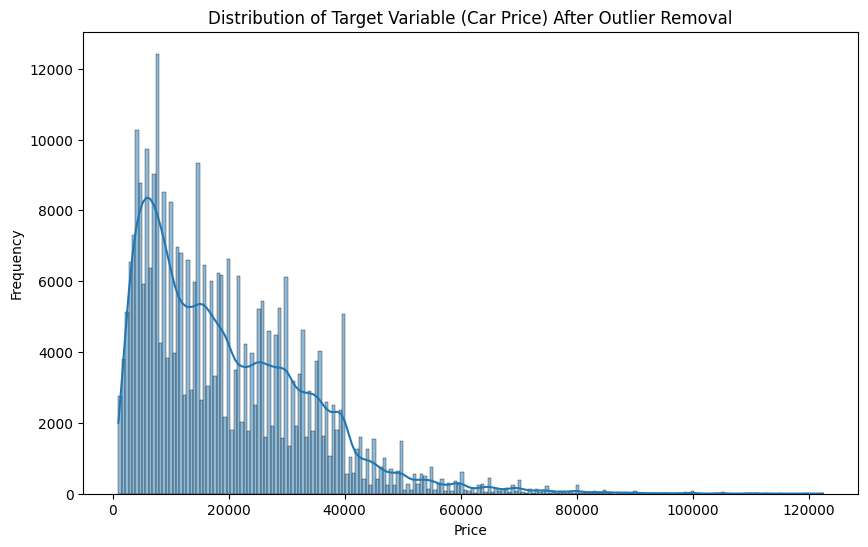

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Target Variable (Car Price) After Outlier Removal')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

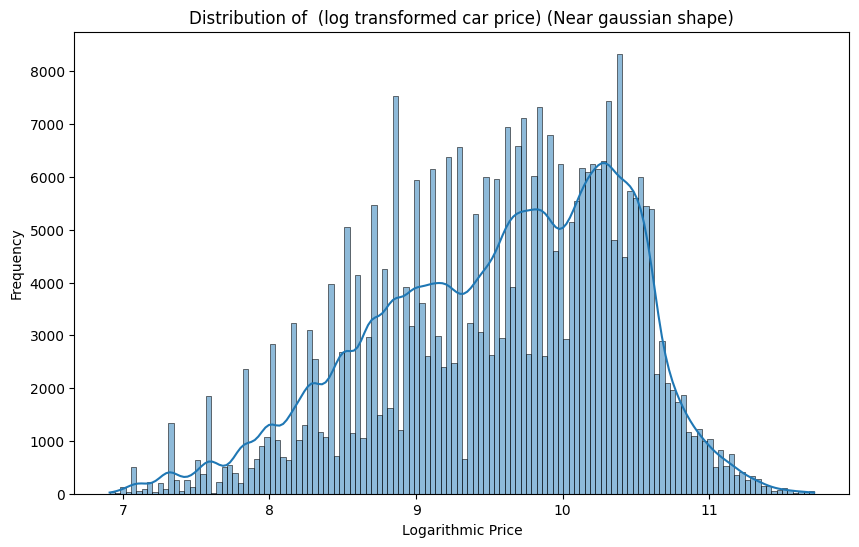

In [15]:
# During EDA , the Targetvalue rice plot looked skewed to left,so we typically take a log_price to normalize the distribution and mitigate impact of outliers.
df['log_price']= np.log(df['price'])
df.drop(columns={'price'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.histplot(df['log_price'], kde=True)
plt.title('Distribution of  (log transformed car price) (Near gaussian shape)')
plt.xlabel('Logarithmic Price')
plt.ylabel('Frequency')
plt.show()
# We can see that the distribution is near normalized now, except some outliers.

# Plot of individual features such as odometer, age, manufacturer,cylinders and target variable log_price

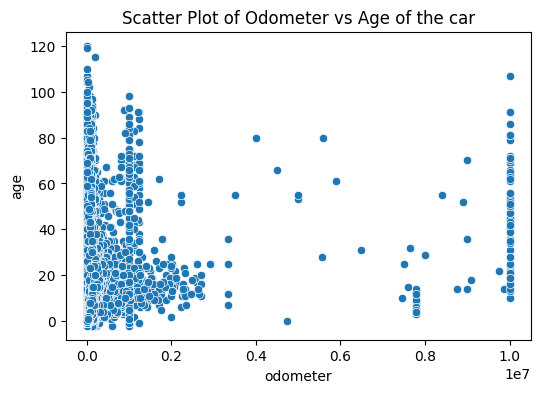

In [17]:
# Note - the kaggle dataset is actually from 2020.
# 'year' can be transformed into Age for a better prediction model and often more interpretable .
df['age']= 2020-df['year']
plt.figure(figsize=(6,4))
#Plot the relation between odometer and age
sns.scatterplot(data=df, x ='odometer',y= 'age')
plt.title('Scatter Plot of Odometer vs Age of the car')
plt.show()

# drop the year and price columns
df = df.drop(columns={'year'})


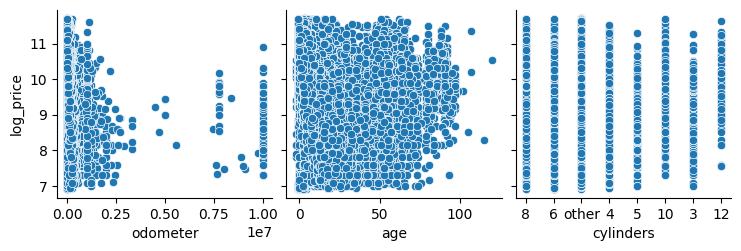

In [51]:
sns.pairplot(df, x_vars=['odometer','age','cylinders'], y_vars='log_price')

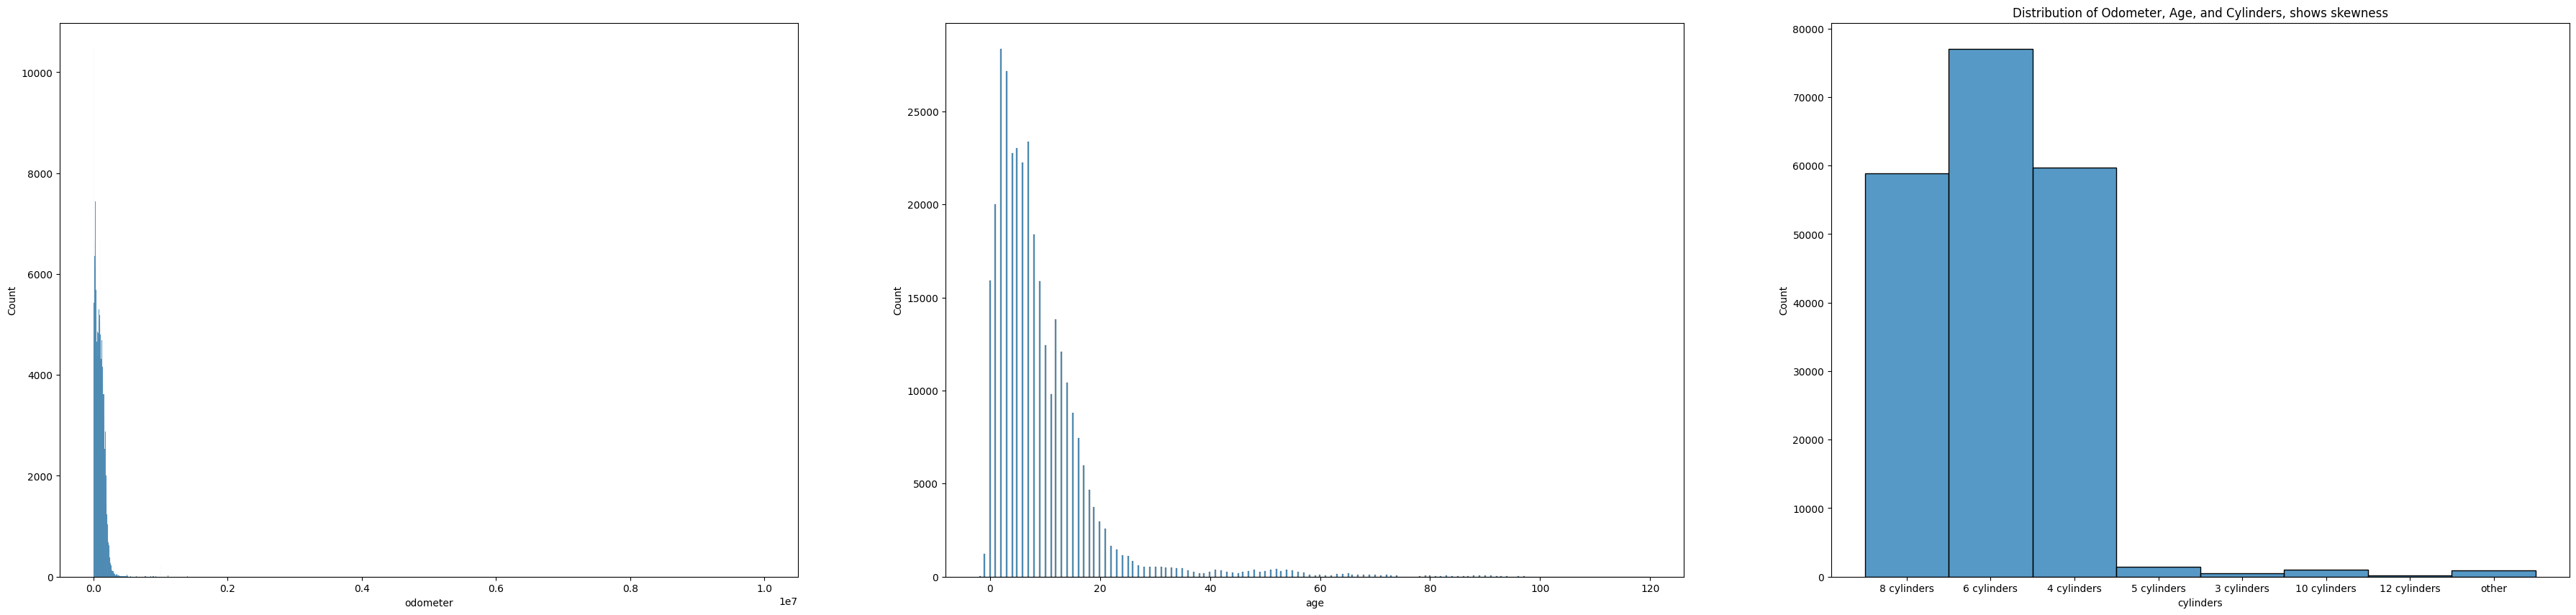

In [19]:
#Plot the distribution of odometer, age and cylinders in subplots
fig, axs = plt.subplots(1, 3, figsize=(45,10))
sns.histplot(df['odometer'], ax=axs[0])
sns.histplot(df['age'], ax=axs[1])
sns.histplot(df['cylinders'], ax=axs[2])
plt.title('Distribution of Odometer, Age, and Cylinders, shows skewness')
plt.show()

In [20]:
# Now,  time to take care of nulls, first print unique values as most columns are  categorical in nature and would need encoding(s) later .
#df.isnull().sum()
print("title_status",df['title_status'].unique())# fill with mode, clear majority of "clean" class
print("cylinders",df['cylinders'].unique())# possibly fill with "others"  # remove cylinders for numerical value # categorical
print("drive",df['drive'].unique())# [nan 'rwd' '4wd' 'fwd'] - # categorical eventually
print("transmission",df['transmission'].unique()) #transmission [nan 'other' 'automatic' 'manual']  # categorical
print("fuel",df['fuel'].unique()) #  categorical
print("paint_color",df['paint_color'].unique()) # categorical
print("manufacturer",df['manufacturer'].unique()) # categorical  (43)
print("model",df['model'].unique()) #  categorical but 30K different ones, need specialized encoding, will see later
print("condition",df['condition'].unique())  #  categorical

title_status [nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']
cylinders [nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cylinders' '3 cylinders'
 '10 cylinders' '12 cylinders' 'other']
drive [nan 'rwd' '4wd' 'fwd']
transmission [nan 'other' 'automatic' 'manual']
fuel [nan 'gas' 'other' 'diesel' 'hybrid' 'electric']
paint_color [nan 'white' 'blue' 'red' 'black' 'silver' 'grey' 'brown' 'yellow'
 'orange' 'green' 'custom' 'purple']
manufacturer [nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'rover'
 'ferrari' 'mini' 'pontiac' 'fiat' 'tesla' 'mercury' 'saturn'
 'harley-davidson' 'datsun' 'aston-martin' 'land rover' 'morgan']
model [nan 'sierra 1500 crew cab slt' 'silverado 1500' ... 'gand wagoneer'
 '96 Suburban' 'Paige Glenbrook Touring']
condition

In [21]:
# Inpsect null values in the dataset , aim to identify null features adding no usability for prediction such as identifiers .
#calculate percentage of missing values for each variable , sorting descending on pct.
Total=df.isnull().sum()
Percent = (df.isnull().sum()*100/df.isnull().count()).sort_values(ascending=False)
# concat the 'Total' and 'Percent' columns using 'concat' function
# pass a list of column names in parameter 'keys'
# 'axis = 1' concats along the columns
missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])
missing_data.sort_values(by='Total', ascending=False)

,Total,Percentage of Missing Values
cylinders,133898,40.147640
condition,117561,35.249195
drive,100760,30.211625
paint_color,92327,27.683096
manufacturer,13481,4.042109
title_status,5297,1.588239
model,3970,1.190355
fuel,2088,0.626061
odometer,1635,0.490234
transmission,1537,0.460850


**New category vs Imputation(Analyzing)**

This part takes care of critical decision whether to create a new class for categorical columns or impute(after train_test_split) with mode or median for (categorical and numerical columns).

From the above tables (unique counts and nulls for each feature), it is clear that *cylinder, drive and paint* have 30-40% missing data, removing nulls would impact the dataset distribution hence we would create a category called 'others' due to no clear majority of the representing classes for each of these features .This is ok to be done before split and is not data leakage as we are not using any statistical decision here.

Other decisions taken are  -
For all other *categorical columns* ,fill with mode after tt_split .
For *numerical columns* odometer and age, fill with median.

**We will perform the Imputations as part of modelling during pipleine building.**

In [22]:
df['model'].value_counts().sort_values(ascending=False) ## close to 30K different models

,count
model,
f-150,5703
silverado 1500,3659
1500,2971
silverado,2298
camry,2227
...,...
JT2bg22k5y0513201,1
colorado z71 diesel,1
b9 tribeca awd,1


**High cardinality data**

*   US states
*   States regions
*   Models




In [23]:
# Unique states and regions
len(df['state'].unique())#  51 us states - keep
len(df['region'].unique())#  404 regions
# would drop regions , too much granularity will cause overfitting and complex model increase computations
df = df.drop(columns={"region"})

In [24]:
# Handle model null values # only
df['model'].isnull().sum()# only np.int64(3970)
# hence can be removed those rows
df = df.dropna(subset=['model'])
df['model'].isnull().sum() # returns 0

# Handle manufacturer null values # does not make sense to impute because make is the brand of the car and most important feature hence drop these null rows
df['manufacturer'].isnull().sum()# only np.int64(13428)
df = df.dropna(subset=['manufacturer'])
df['manufacturer'].isnull().sum()


np.int64(0)

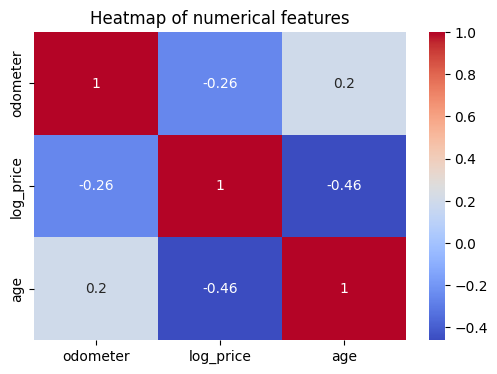

In [25]:
# Plot heatmap of numerical columns to see if there is some multicollinearity
# 1. Select only numerical features
numeric_df = df.select_dtypes(include=['number'])

# 2. Compute the correlation matrix
corr_matrix = numeric_df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap of numerical features")
plt.show()
# Not a very high corr in numerical columns which is a good sign - Goes with general understanding with older cars causing lower prices(logarithmic though monotonic) .

In [26]:
# Transform the cylinder column from string to numeric
df['cylinders']=df['cylinders'].str.split(" ").str[0]
df['cylinders'].isnull().sum() # np.int64(126465)
df['cylinders'].value_counts(ascending=True)# dominated by 6 cylinders

,count
cylinders,
12,93
3,394
other,757
10,997
5,1290
8,55313
4,57102
6,73705


In [27]:
df.isnull().sum()

,0
manufacturer,0
model,0
condition,111305
cylinders,126465
fuel,1733
odometer,1530
title_status,4883
transmission,1421
drive,94207
paint_color,86510


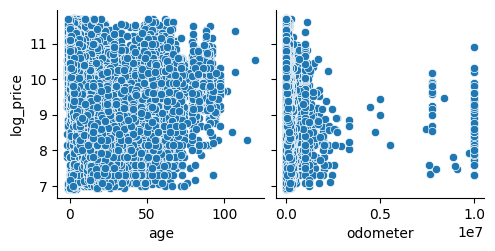

In [28]:
# Visualize relationships between numeric features and target var log price
sns.pairplot(df, x_vars=['age','odometer'], y_vars='log_price')
plt.show()
# some indication that lower mileage of car (lesser travelled) lead to higher prices.

In [29]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(df.describe())
pd.reset_option('display.float_format')

          odometer  log_price        age
count   314586.000 316116.000 316113.000
mean     95177.542      9.583      8.648
std     167138.874      0.834      8.970
min          0.000      6.910     -2.000
25%      36051.000      8.987      3.000
50%      85000.000      9.711      7.000
75%     135000.000     10.240     12.000
max   10000000.000     11.712    120.000


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [30]:
# Now split the dataset into X and y before split .
X = df.drop(columns =['log_price'])
y = df['log_price']
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
# Add additional class 'other' for features as disucssed earlier - cylinders, drive and paint
# Following  imputation can be done before split as well , no statistical props used and just a new class other being created as part of the feature
other_imputer_columns=['paint_color','drive','cylinders']
for column in other_imputer_columns:
    df[column].fillna('other', inplace=True)

**Preprocessor Transformation Before model building pipeline**

Due to great variations in data types of features , we would follow the following column transformations , followed by the model pipeline definition.

Preprocessor (ColumnTransformer)

1.Numeric columns:
   Median Imputer
   → optional scaler

2.Categorical columns:
   Mode Imputer
   → One-hot encoding

3. High-cardinality column:
   Mode Imputer
   → Frequency encoding (TargetEncoding)

And then,
**Final Pipeline**
Preprocessor
→ Model


**Build a table of features and define whether numeric and needs scaling or encoding**
categorical - manufacturer,cylinders,fuel,title_status,transmission,drive, paint_color,state, condition

numeric - odometer, age

model of the car - frequency encoding to preserve the distribution






In [32]:
#Unique models are
print(len(df['model'].value_counts()))#27K models
#I want to reduce cardinality but model is important (since we removed type and size both), hence we will  use frequency encoder during sklearn pipeline.
model_counts= df['model'].value_counts(ascending=False)
#X_train['model'].value_counts()


21724


In [56]:
categorical_features= ['manufacturer', 'fuel', 'title_status', 'transmission', 'drive', 'paint_color', 'state', 'cylinders', 'condition']
numerical_features = ['odometer','age']
frequency_encoder_features = ['model']

# Find the column in df that does not belong to the below features
df.columns[~df.columns.isin(categorical_features + numerical_features + frequency_encoder_features)] ## Only log_price , all columns taken care of

Index(['log_price'], dtype='object')

In [57]:
# Define preprocessing for numerical , categorical,  high-cardinal features(model above)
numeric_transformer = Pipeline(steps= [("simple_imputer",SimpleImputer(strategy='median')), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps= [("simple_imputer",SimpleImputer(strategy='most_frequent')),("onehotencoder", OneHotEncoder(drop='first',handle_unknown='ignore'))])

#Added StandardScaler to the frequency_transformer as well for 'model'  column
frequency_transformer = Pipeline(steps= [("simple_imputer",SimpleImputer(strategy='most_frequent')),("frequency_encoder", TargetEncoder()), ("scaler", StandardScaler())])

In [74]:
preprocessor = ColumnTransformer (remainder='passthrough',
    transformers= [
        ("categorical_transformer", categorical_transformer, categorical_features),
        ("numeric_transformer", numeric_transformer, numerical_features),
        ("frequency_transformer", frequency_transformer, frequency_encoder_features) # Temporarily commented out
    ]
)

In [75]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical_transformer',
                                 Pipeline(steps=[('simple_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['manufacturer', 'fuel', 'title_status',
                                  'transmission', 'drive', 'paint_color',
                                  'state', 'cylinders', 'condition']),
                                ('numeric_transformer',
                                 Pipeline(steps=[('simple_imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['odometer', 'age']),
                                ('frequency_transformer',
                                 Pipeline(steps=[('simple_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('frequency_encoder',
                                                  TargetEncoder()),
                                                 ('scaler', StandardScaler())]),
                                 ['model'])])

In [76]:
# Now , create a pipeline for baseline Linear regression
pipeline_linear_model= Pipeline(steps=[("preprocesor",preprocessor),('linear_regression',LinearRegression())])
pipeline_linear_model.fit(X_train,y_train)

Pipeline(steps=[('preprocesor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical_transformer',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['manufacturer', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'paint_color', 'state',
                                                   'cylin...
                                                 ('numeric_transformer',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['odometer', 'age']),
                                                 ('frequency_transformer',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('frequency_encoder',
                                                                   TargetEncoder()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['model'])])),
                ('linear_regression', LinearRegression())])

In [77]:
# Make predictions and calculated errors for the basic model.
y_preds=pipeline_linear_model.predict(X_test)
print("MSE for linear model : ",mean_squared_error(y_test,y_preds))
print("RMSE for linear model : ",np.sqrt(mean_squared_error(y_test,y_preds)))
print("R2 score for linear model : ",r2_score(y_test,y_preds))
# MSE for linear model :  0.24064226591494786
# RMSE for linear model :  0.4905530204931449
# R2 score for linear model :  0.6539770789878381

MSE for linear model :  0.2406545161449807
RMSE for linear model :  0.49056550647694414
R2 score for linear model :  0.6539594642086433


In [ ]:
# R2 score(1 - MSEmodel/ MSEmeanbaseleine) above indicates that 65% of the variance is explained by the featues , quite close to 1 .


In [79]:
#Create a dataframe with columns y_preds and y_actual - These are logarithmic prices
pd.DataFrame({'y_preds': y_preds, 'y_test': y_test}).tail(5)

,y_preds,y_test
324914,9.483895,9.047821
408954,10.746125,10.858980
370819,9.259900,8.955319
88864,10.369647,10.560748
216698,9.780481,9.581904


In [82]:
#Create a dataframe with columns y_preds and y_actual but the actual prices without log
pd.DataFrame({'y_preds': np.exp(y_preds), 'y_test': np.exp(y_test)}).tail(5)

,y_preds,y_test
324914,13146.290037,8500.0
408954,46449.684839,51999.0
370819,10508.078730,7749.0
88864,31877.228051,38590.0
216698,17685.155613,14500.0


In [85]:
np.sqrt(mean_squared_error(np.exp(y_test),np.exp(y_preds)))

np.float64(8337.113293870085)

In [40]:
# Prepare all possible regression models for prediction and evaluation, linear regression would be used as a baseline
reg_models = [
    ('ridge',Pipeline(steps=[("preprocesor",preprocessor),('ridge_regression',Ridge())])),
    ('elastic_net',Pipeline(steps=[("preprocesor",preprocessor),('elastic_net_regression',ElasticNet())])),
    ('lasso',Pipeline(steps=[("preprocesor",preprocessor),('lasso_regression',Lasso())]))
    ]
# create a dictionary for storing MSE and R2_score each
model_mse_scores = {}
model_r2_scores = {}

In [41]:
# Train and evaluate regularization models
results = {}
for name, pipe_model in reg_models:
    pipe_model.fit(X_train, y_train)
    y_pred = pipe_model.predict(X_test)
    mse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name}: MSE = {mse:.4f},RMSE = {rmse:.4f}, R2 = {r2:.4f}")

coefs = pipe_model.named_steps["lasso_regression"].coef_
intercept = pipe_model.named_steps["lasso_regression"].intercept_
print("Coefficients:", coefs)
print("Intercept:", intercept)

print("MSE for linear model : ",mean_squared_error(y_test,y_preds))
print("RMSE for linear model : ",np.sqrt(mean_squared_error(y_test,y_preds)))
print("R2 score for linear model : ",r2_score(y_test,y_preds))

ridge: MSE = 0.4905,RMSE = 0.7004, R2 = 0.6540
elastic_net: MSE = 0.7823,RMSE = 0.8845, R2 = 0.1200
lasso: MSE = 0.8339,RMSE = 0.9132, R2 = -0.0000
Coefficients: [ 0.  0.  0.  0. -0.  0.  0. -0. -0. -0.  0. -0.  0.  0. -0. -0. -0.  0.
  0.  0. -0. -0.  0.  0. -0.  0. -0. -0. -0. -0. -0.  0.  0.  0. -0. -0.
  0. -0. -0. -0.  0. -0. -0.  0.  0. -0. -0. -0. -0. -0.  0. -0.  0. -0.
 -0. -0. -0. -0.  0. -0.  0. -0.  0. -0.  0.  0.  0.  0. -0. -0. -0. -0.
 -0.  0.  0. -0.  0. -0.  0.  0.  0.  0. -0. -0. -0. -0. -0.  0. -0.  0.
  0. -0. -0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0.
 -0. -0.  0. -0.  0.  0.  0. -0. -0. -0.  0.  0.  0. -0.  0.  0.  0. -0.
 -0. -0.  0.]
Intercept: 9.582863557630686
MSE for linear model :  0.24064226591494786
RMSE for linear model :  0.4905530204931449
R2 score for linear model :  0.6539770789878381


Lasso R2_score is 0 -  which implies 1 -MSE(lasso)/MSE(baseline) =0 ie lasso is just predicting the mean of the target variable effectively reducing all of the feature coefs to 0 as shown above
This is hence overregularization and not a good model with default alpha hyper param value 1.0.  Hence , try with different values of alpha in param grid used in cross validation by GridSearchCV

In [42]:
regularization_models = [
    ('ridgea', Pipeline(steps=[("preprocessor", preprocessor), ('ridgea_regression', Ridge(alpha=0.01))])),
    ('lassoa', Pipeline(steps=[("preprocessor", preprocessor), ('lassoa_regression', Lasso(alpha=0.0001))])),
    ('elastic_neta', Pipeline(steps=[("preprocessor", preprocessor), ('elastic_neta_regression', ElasticNet(alpha=0.0001))])),
]

# Train and evaluate regularization models
results = {}
for name, pipe_model in regularization_models:
    pipe_model.fit(X_train, y_train)
    y_pred = pipe_model.predict(X_test)
    mse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name}: MSE = {mse:.4f},RMSE = {rmse:.4f}, R2 = {r2:.4f}")




ridgea: MSE = 0.4905,RMSE = 0.7004, R2 = 0.6540
lassoa: MSE = 0.4912,RMSE = 0.7009, R2 = 0.6531
elastic_neta: MSE = 0.4910,RMSE = 0.7007, R2 = 0.6533


**Cross Validation and Hyperparameter Tuning**



In [43]:
# From the result above , it seems baseline Linear regression is giving better results than other models but let's try hyper parameter tuning on reg models to find the best estimators for these and then
# compare against the baseline model.

In [44]:
# make it computationally viable with limited values
param_grid_ridge ={
    "ridge_regression__alpha" : [0.1,1.0,10.0,100.0]# make it computationally viable with limited values
}
param_grid_lasso ={
    "lasso_regression__alpha" : [0.01, 0.1, 1.0, 10.0]# make it computationally viable with limited values
}
param_grid_elastic_net ={# take l1_ratio as well to balance L1 and L2
    "elastic_net_regression__alpha" : {'alpha': [0.01, 0.1, 1.0, 10.0], 'l1_ratio': [0.1, 0.5, 0.7, 0.9]}# make it computationally viable with limited values
}

In [45]:
# Evaluate grid search for each of the models one by one , that need regularization. # make it computationally viable with limited values
grid_search= GridSearchCV(Pipeline(steps=[("preprocesor",preprocessor),('ridge_regression',Ridge())]), param_grid_ridge ,cv=5 ,scoring='neg_mean_squared_error')
grid_search.fit(X_train,y_train)
grid_search.best_params_
grid_search.best_score_

np.float64(-0.24314909617197972)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Checklist for a proper submission

Built baseline Linear Regression

Showed coefficient interpretation

Compared Ridge vs Lasso

Did cross-validation properly

Discussed overfitting

And most importantly:

Explained results in business language.

In [46]:
# Do plot the error which is (y_pred-y) to see a normalized curve

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [47]:
# What features make a car more or less expensive .


In [48]:
# Provide clear recommedations to used car dealers about what customers value in a used car


In [49]:
# From existing experience , you can tailor your findings towards manufacturer's dealerships and private individual car dealers distinctively .

**Limitations**

**Generalization to new makes** When new car brands and models come out , there wouldnt be enough data to make accurate predictions as there would be many unknowns in the existing features.

**Time based sales** Car sales is also heavily impacted by seasonal variations including festivals and occassions such as year end when demand is high due to holiday season, hence the algo has to evolve to consider time series data for dealers to price vehicles in order to make more profits .

**Manufacturing warranty**- Customers increasingly value existing warranty offered by original manufacturer which normally lasts for 3 years and hence in spite of a general assumption that car depreciates heavily in the first 3 years , this is an important factor to consider as desirability of customers would be high for buying such cars.

**Consumer preference** The above dataset does not have any indicator for consumer preference hence additional segmentation data is required for brand conscious customers (and could afford) who would buy only elite brands vs medium-tier customers hence in real-world sophisticated models are needed tailored for different brands.

**Next steps with recommendations**

**Luxury tax** Some features of a car are region specific , for eg - In the UK, we are required to pay luxury tax on top of regular tax for each year for vehicles having RRP > 40K £ . Hence , a feature like “IsLuxTaxPayable” can be a critical determinant for some purchasers especially when even for the same car brand and model and same manufacturing year, a submodel can edge past the RRP beyond 40K threshold . This is called Luxury Trap here in the UK and adds to running costs of vehicles.
Other features of interest and in normal practice

1.**Front wheel drive** - Geography is important here as in hilly areas (such as Scotland which is also in UK), stability  of cars is more important hence 2.
**All-wheel-drive** (instead of FWD ) is more desirable to customers and often shoots up prices.

2.**Running Costs(Maintenance)**- Insurance group taken into consideration for pricing vehicles because luxury cars often have higher premiums. Annual Servicing charges also are a factor with preium cars.

3.**Accident history of cars**(AccidentCategory -  S/N/NaN) - Whether the car had an accident category , whether the damage was structural or non-structural. significantly lowers the price relatively .

4.**Manufacturer approved** - Whether car dealer belongs to official manufacturers  dealerships such as BMW , Porsche or private dealers .

**Checklist for a proper submission**

Built baseline Linear Regression

Showed coefficient interpretation

Compared Ridge vs Lasso

Did cross-validation properly

Discussed overfitting

And most importantly:

Explained results in business language.